In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



# Importar datos

Datos tomados de https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv

In [ ]:
diabetes_df = pd.read_csv('/content/diabetes_dataset.csv')
diabetes_df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Preparar los datos y Construir el algoritmo

### Separar los datos

In [ ]:
X = diabetes_df.drop('Diabetes_binary', axis=1)
y = diabetes_df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

In [ ]:
print(X_train.shape, X_test.shape)

(63622, 21) (7070, 21)


In [ ]:
print(y_train.shape, y_test.shape)

(63622,) (7070,)


## EDA Analisis exploratorio de datos

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.000000,0.381516,0.289213,0.115382,0.293373,0.085999,0.125427,0.211523,-0.158666,-0.054077,...,0.023191,0.040977,0.407612,0.087029,0.213081,0.272646,0.044413,0.278738,-0.170481,-0.224449
HighBP,0.381516,1.000000,0.316515,0.103283,0.241019,0.087438,0.129060,0.210750,-0.136102,-0.040852,...,0.035764,0.026517,0.320540,0.064294,0.173922,0.234784,0.040819,0.338132,-0.141643,-0.187657
HighChol,0.289213,0.316515,1.000000,0.085981,0.131309,0.093398,0.099786,0.181187,-0.090453,-0.047384,...,0.031532,0.033199,0.237778,0.083881,0.142610,0.162043,0.017324,0.240338,-0.084386,-0.107777
CholCheck,0.115382,0.103283,0.085981,1.000000,0.045648,-0.004331,0.022529,0.043497,-0.008249,0.017384,...,0.106800,-0.062669,0.059213,-0.010660,0.034540,0.044430,-0.007991,0.101743,-0.008695,0.007550
BMI,0.293373,0.241019,0.131309,0.045648,1.000000,0.011551,0.022931,0.060355,-0.170936,-0.084505,...,-0.013417,0.065832,0.267888,0.104682,0.161862,0.246094,0.000827,-0.038648,-0.100233,-0.124878
Smoker,0.085999,0.087438,0.093398,-0.004331,0.011551,1.000000,0.064658,0.124418,-0.079823,-0.074811,...,-0.012939,0.035799,0.152416,0.091257,0.120698,0.119789,0.112125,0.105424,-0.140966,-0.104725
Stroke,0.125427,0.129060,0.099786,0.022529,0.022931,0.064658,1.000000,0.223394,-0.079985,-0.008996,...,0.006484,0.036198,0.189447,0.087303,0.164488,0.192266,0.003822,0.123879,-0.073926,-0.136577
HeartDiseaseorAttack,0.211523,0.210750,0.181187,0.043497,0.060355,0.124418,0.223394,1.000000,-0.098223,-0.019436,...,0.015687,0.036029,0.275868,0.075057,0.198416,0.232611,0.098161,0.221878,-0.096559,-0.146748
PhysActivity,-0.158666,-0.136102,-0.090453,-0.008249,-0.170936,-0.079823,-0.079985,-0.098223,1.000000,0.133813,...,0.027089,-0.063302,-0.273548,-0.130090,-0.234500,-0.276868,0.051753,-0.100753,0.190271,0.196551
Fruits,-0.054077,-0.040852,-0.047384,0.017384,-0.084505,-0.074811,-0.008996,-0.019436,0.133813,1.000000,...,0.029385,-0.045843,-0.098687,-0.062102,-0.048572,-0.050784,-0.088723,0.061096,0.098715,0.079009


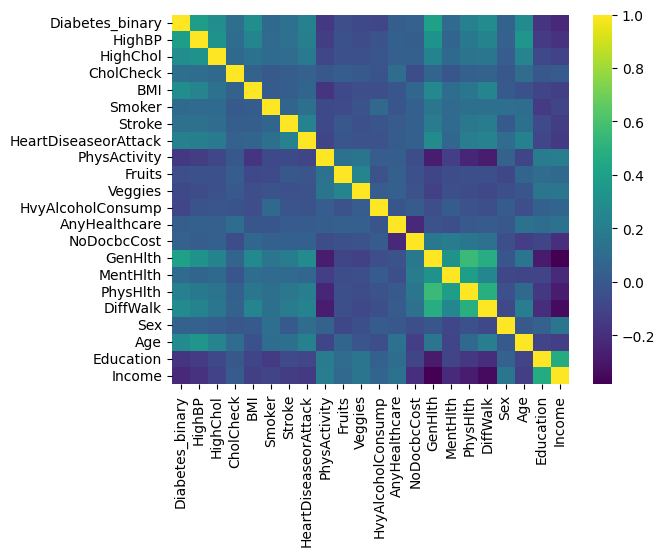

In [ ]:
import seaborn as sns

mc = sns.heatmap(diabetes_df.corr(), cmap = 'viridis')

diabetes_df.corr()


### Instanciar el modelo y usar .fit() con los datos de entrenamiento

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
clasificador = RandomForestClassifier()
clasificador.fit(X_train, y_train)

RandomForestClassifier()

### Realizar predicciones sobre el conjunto de prueba

In [ ]:
y_pred = clasificador.predict(X_test)

### Evaluacion del algoritmo

#### Matriz de confusion
La matriz de confusión es una herramienta de evaluación para modelos de aprendizaje automático supervisado (clasificación) que resume el rendimiento de un modelo comparando los valores predichos con los reales

![image.png](attachment:image.png)

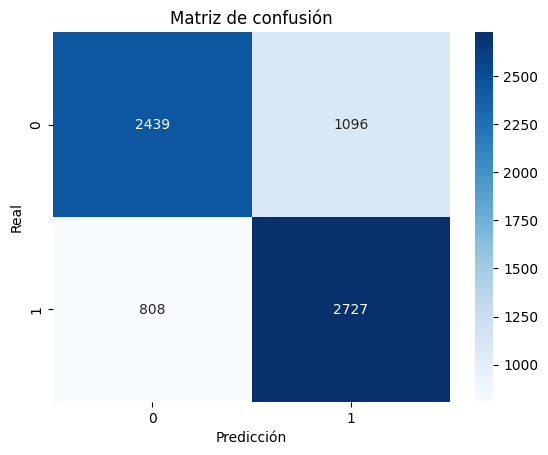

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [ ]:
X_test.shape

(7070, 21)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.69      0.72      3535
         1.0       0.71      0.77      0.74      3535

    accuracy                           0.73      7070
   macro avg       0.73      0.73      0.73      7070
weighted avg       0.73      0.73      0.73      7070



Otra manera de entender las métricas:

- Accuracy: ¿Cuántas veces acertó en total el modelo? --> Sirve cuando el dataset está balanceado
- Precision: De todo lo que el modelo predijo como positivo, ¿Que porcentaje de estos eran correcto? --> Me sirve para evitar falsos positivos
- Recall: De todos los positivos reales, ¿¿Que porcentaje de estos encontró el modelo? --> Me sirve para evitar falsos negativos
- F1-Score: Balance entre Precision y Recall --> Sirve cuando el dataset NO está balanceado

# Ajuste de hiperparámetros

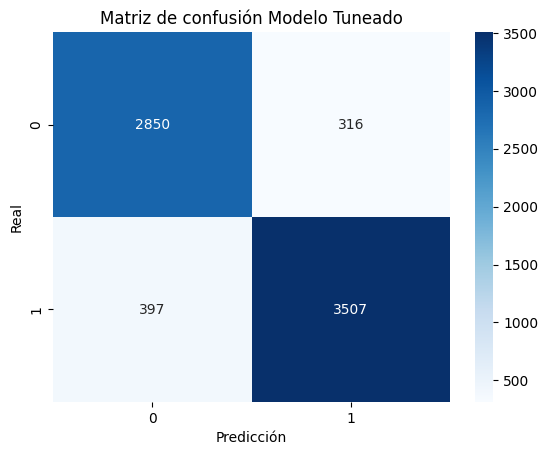

              precision    recall  f1-score   support

         0.0       0.77      0.69      0.73      3535
         1.0       0.72      0.79      0.76      3535

    accuracy                           0.74      7070
   macro avg       0.75      0.74      0.74      7070
weighted avg       0.75      0.74      0.74      7070



In [ ]:
clasificador_tuneado = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=6,
    min_samples_leaf=3,
    random_state=42
)

clasificador_tuneado.fit(X_train, y_train)
y_pred_tuneado = clasificador_tuneado.predict(X_test)
cm = confusion_matrix(y_pred_tuneado, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión Modelo Tuneado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()
print(classification_report(y_test, y_pred_tuneado))

In [ ]:
## GridSearch CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [20, 50],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')

cv.fit(X_train, y_train)
print(f'Mejor modelo: {cv.best_estimator_}')
y_pred_cv = cv.predict(X_test)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejor modelo: RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=200,
                       random_state=42)


              precision    recall  f1-score   support

         0.0       0.76      0.69      0.72      3535
         1.0       0.72      0.79      0.75      3535

    accuracy                           0.74      7070
   macro avg       0.74      0.74      0.74      7070
weighted avg       0.74      0.74      0.74      7070



Text(50.722222222222214, 0.5, 'Real')

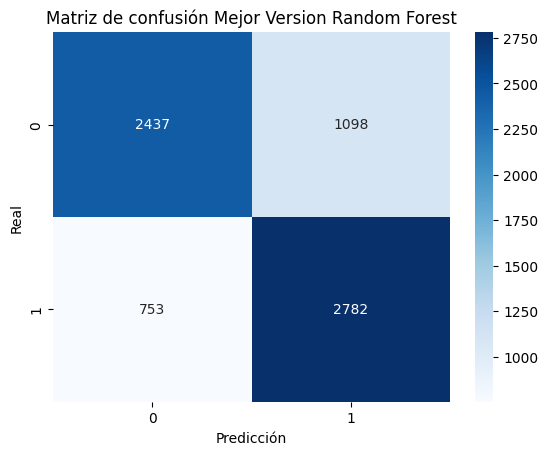

In [ ]:
cm = confusion_matrix(y_test, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(classification_report(y_test, y_pred_cv))
plt.title(f'Matriz de confusión Mejor Version Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')


# Ajuste de hiperparametros para KNN  (K Nearest Neighbors)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()


param_grid = {
    'n_neighbors': [3,5,8,12],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute']
}

## Estimtor = Instancia del modelo que queremos tunear
## param_grid = Diccionario con los hiperparámetros que queremos probar
## cv = Número de pliegues para la validación cruzada (Pliegues = Subconjuntos del conjunto original de los datos)
## n_jobs = Número de núcleos a utilizar para el procesamiento paralelo (-1 utiliza todos los núcleos disponibles)
## scoring = Métrica que se utilizará para evaluar el rendimiento de los modelos durante la búsqueda (en este caso, 'recall' para maximizar la capacidad de detectar casos positivos)

cv = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')


cv.fit(X_train, y_train)
print(f'Mejor modelo: {cv.best_estimator_}')
y_pred_cv = cv.predict(X_test)


Mejor modelo: KNeighborsClassifier(algorithm='brute', n_neighbors=12, weights='distance')


              precision    recall  f1-score   support

         0.0       0.73      0.68      0.71      3535
         1.0       0.70      0.75      0.73      3535

    accuracy                           0.72      7070
   macro avg       0.72      0.72      0.72      7070
weighted avg       0.72      0.72      0.72      7070



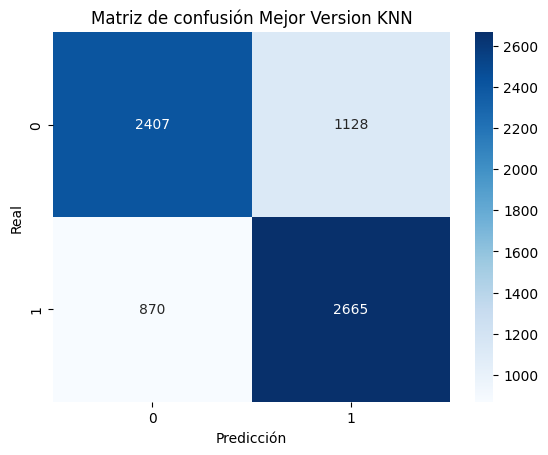

In [ ]:
cm = confusion_matrix(y_test, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(classification_report(y_test, y_pred_cv))
plt.title(f'Matriz de confusión Mejor Version KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Ajuste de hiperparametros para XGBOOSTING

In [ ]:
from xgboost import XGBClassifier


xgb_clasificador = XGBClassifier()

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
}

## Estimtor = Instancia del modelo que queremos tunear
## param_grid = Diccionario con los hiperparámetros que queremos probar
## cv = Número de pliegues para la validación cruzada (Pliegues = Subconjuntos del conjunto original de los datos)
## n_jobs = Número de núcleos a utilizar para el procesamiento paralelo (-1 utiliza todos los núcleos disponibles)
## scoring = Métrica que se utilizará para evaluar el rendimiento de los modelos durante la búsqueda (en este caso, 'recall' para maximizar la capacidad de detectar casos positivos)

cv = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')


cv.fit(X_train, y_train)
print(f'Mejor modelo: {cv.best_estimator_}')
y_pred_cv = cv.predict(X_test)


Mejor modelo: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
cm = confusion_matrix(y_test, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(classification_report(y_test, y_pred_cv))
plt.title(f'Matriz de confusión Mejor Version XGB')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()